In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy torch torchvision segmentation-models-pytorch scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.0 MB/s eta 0:00:00


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [5]:
%%writefile src/metrics.py
import numpy as np
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric


def denormalize_to_hu(image_norm, min_hu=-1000, max_hu=1600):

    image = (image_norm + 1.0) / 2.0
    image = image * (max_hu - min_hu) + min_hu
    return image.astype(np.float32)


def mae_hu(pred_hu, target_hu, mask=None):

    error = np.abs(pred_hu - target_hu)

    if mask is not None:
        mask = mask > 0
        return error[mask].mean()

    return error.mean()


def rmse_hu(pred_hu, target_hu, mask=None):

    error_sq = (pred_hu - target_hu) ** 2

    if mask is not None:
        mask = mask > 0
        return np.sqrt(error_sq[mask].mean())

    return np.sqrt(error_sq.mean())


def psnr_hu(pred_hu, target_hu, data_range=2600, mask=None):

    if mask is not None:
        mask = mask > 0


        pred_values = pred_hu[mask]
        target_values = target_hu[mask]

        mse = np.mean((pred_values - target_values) ** 2)
        if mse == 0:
            return float("inf")

        return 20 * np.log10(data_range / np.sqrt(mse))

    return psnr_metric(target_hu, pred_hu, data_range=data_range)


def ssim_hu(pred_hu, target_hu, data_range=2600):

    return ssim_metric(target_hu, pred_hu, data_range=data_range)


def region_masks_from_ct(ct_hu, body_mask=None):

    if body_mask is None:
        body_mask = np.ones_like(ct_hu, dtype=bool)
    else:
        body_mask = body_mask > 0

    air_lung = (ct_hu < -300) & body_mask
    soft_tissue = (ct_hu >= -300) & (ct_hu <= 200) & body_mask
    bone = (ct_hu > 200) & body_mask

    return {
        "air_lung": air_lung,
        "soft_tissue": soft_tissue,
        "bone": bone,
        "body": body_mask
    }


def calculate_all_metrics(pred_norm, target_norm, input_norm=None, mask=None, min_hu=-1000, max_hu=1600):

    pred_hu = denormalize_to_hu(pred_norm, min_hu, max_hu)
    target_hu = denormalize_to_hu(target_norm, min_hu, max_hu)

    if input_norm is not None:
        input_hu = denormalize_to_hu(input_norm, min_hu, max_hu)
    else:
        input_hu = None

    if mask is not None:
        mask = mask > 0

    results = {}

    results["sct_mae_hu"] = mae_hu(pred_hu, target_hu, mask)
    results["sct_rmse_hu"] = rmse_hu(pred_hu, target_hu, mask)
    results["sct_psnr"] = psnr_hu(pred_hu, target_hu, data_range=max_hu-min_hu, mask=mask)
    results["sct_ssim"] = ssim_hu(pred_hu, target_hu, data_range=max_hu-min_hu)

    if input_hu is not None:
        results["raw_cbct_mae_hu"] = mae_hu(input_hu, target_hu, mask)
        results["raw_cbct_rmse_hu"] = rmse_hu(input_hu, target_hu, mask)
        results["raw_cbct_psnr"] = psnr_hu(input_hu, target_hu, data_range=max_hu-min_hu, mask=mask)
        results["raw_cbct_ssim"] = ssim_hu(input_hu, target_hu, data_range=max_hu-min_hu)

    region_masks = region_masks_from_ct(target_hu, body_mask=mask)

    for region_name, region_mask in region_masks.items():
        if region_mask.sum() > 0:
            results[f"sct_mae_{region_name}_hu"] = mae_hu(pred_hu, target_hu, region_mask)

            if input_hu is not None:
                results[f"raw_cbct_mae_{region_name}_hu"] = mae_hu(input_hu, target_hu, region_mask)
        else:
            results[f"sct_mae_{region_name}_hu"] = np.nan

            if input_hu is not None:
                results[f"raw_cbct_mae_{region_name}_hu"] = np.nan

    return results

Writing src/metrics.py


In [6]:
from src.dataset import SynthRAD2p5DDataset
from src.model import build_unetplusplus_resnet34
from src.metrics import calculate_all_metrics, denormalize_to_hu

df = pd.read_csv("data/patient_list.csv")

with open("splits/fold_0.json", "r") as f:
    split = json.load(f)

val_dataset = SynthRAD2p5DDataset(
    dataframe=df,
    patient_ids=split["val"],
    input_slices=7,
    image_size=320,
    min_hu=-1000,
    max_hu=1600,
    max_patients=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("Validation samples:", len(val_dataset))

Validation samples: 152


In [7]:
model = build_unetplusplus_resnet34(
    in_channels=7,
    out_channels=1,
    encoder_weights=None,
    dropout=0.2
).to(device)

checkpoint_path = "checkpoints/test_training/best_fold0.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint:", checkpoint_path)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Checkpoint val loss:", checkpoint["val_loss"])

Loaded checkpoint: checkpoints/test_training/best_fold0.pth
Checkpoint epoch: 2
Checkpoint val loss: 0.08724341509134872


In [8]:
batch = next(iter(val_loader))

inputs = batch["input"].to(device)
targets = batch["target"].to(device)
masks = batch["mask"].to(device)

with torch.no_grad():
    outputs = model(inputs)

input_center = inputs[0, 3].cpu().numpy()
target_slice = targets[0, 0].cpu().numpy()
pred_slice = outputs[0, 0].cpu().numpy()
mask_slice = masks[0, 0].cpu().numpy()

metrics = calculate_all_metrics(
    pred_norm=pred_slice,
    target_norm=target_slice,
    input_norm=input_center,
    mask=mask_slice,
    min_hu=-1000,
    max_hu=1600
)

metrics

{'sct_mae_hu': np.float32(132.61513),
 'sct_rmse_hu': np.float32(207.13933),
 'sct_psnr': np.float32(21.974218),
 'sct_ssim': np.float64(-0.00821208326135499),
 'raw_cbct_mae_hu': np.float32(134.80681),
 'raw_cbct_rmse_hu': np.float32(210.96248),
 'raw_cbct_psnr': np.float32(21.815365),
 'raw_cbct_ssim': np.float64(0.809853723010998),
 'sct_mae_air_lung_hu': np.float32(217.80403),
 'raw_cbct_mae_air_lung_hu': np.float32(224.42207),
 'sct_mae_soft_tissue_hu': np.float32(77.67957),
 'raw_cbct_mae_soft_tissue_hu': np.float32(85.4522),
 'sct_mae_bone_hu': np.float32(237.26134),
 'raw_cbct_mae_bone_hu': np.float32(204.6464),
 'sct_mae_body_hu': np.float32(132.61513),
 'raw_cbct_mae_body_hu': np.float32(134.80681)}

In [9]:
print("Raw CBCT vs CT")
print("MAE:", metrics["raw_cbct_mae_hu"])
print("RMSE:", metrics["raw_cbct_rmse_hu"])
print("PSNR:", metrics["raw_cbct_psnr"])
print("SSIM:", metrics["raw_cbct_ssim"])

print("\nPredicted sCT vs CT")
print("MAE:", metrics["sct_mae_hu"])
print("RMSE:", metrics["sct_rmse_hu"])
print("PSNR:", metrics["sct_psnr"])
print("SSIM:", metrics["sct_ssim"])

print("\nRegion-wise MAE")
print("Raw CBCT body MAE:", metrics["raw_cbct_mae_body_hu"])
print("sCT body MAE:", metrics["sct_mae_body_hu"])

print("Raw CBCT bone MAE:", metrics["raw_cbct_mae_bone_hu"])
print("sCT bone MAE:", metrics["sct_mae_bone_hu"])

print("Raw CBCT soft tissue MAE:", metrics["raw_cbct_mae_soft_tissue_hu"])
print("sCT soft tissue MAE:", metrics["sct_mae_soft_tissue_hu"])

print("Raw CBCT air/lung MAE:", metrics["raw_cbct_mae_air_lung_hu"])
print("sCT air/lung MAE:", metrics["sct_mae_air_lung_hu"])

Raw CBCT vs CT
MAE: 134.80681
RMSE: 210.96248
PSNR: 21.815365
SSIM: 0.809853723010998

Predicted sCT vs CT
MAE: 132.61513
RMSE: 207.13933
PSNR: 21.974218
SSIM: -0.00821208326135499

Region-wise MAE
Raw CBCT body MAE: 134.80681
sCT body MAE: 132.61513
Raw CBCT bone MAE: 204.6464
sCT bone MAE: 237.26134
Raw CBCT soft tissue MAE: 85.4522
sCT soft tissue MAE: 77.67957
Raw CBCT air/lung MAE: 224.42207
sCT air/lung MAE: 217.80403


In [10]:
os.makedirs("results/metrics", exist_ok=True)

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("results/metrics/day8_metrics_preview.csv", index=False)

metrics_df

,sct_mae_hu,sct_rmse_hu,sct_psnr,sct_ssim,raw_cbct_mae_hu,raw_cbct_rmse_hu,raw_cbct_psnr,raw_cbct_ssim,sct_mae_air_lung_hu,raw_cbct_mae_air_lung_hu,sct_mae_soft_tissue_hu,raw_cbct_mae_soft_tissue_hu,sct_mae_bone_hu,raw_cbct_mae_bone_hu,sct_mae_body_hu,raw_cbct_mae_body_hu
0,132.615128,207.139328,21.974218,-0.008212,134.806808,210.962479,21.815365,0.809854,217.804031,224.422073,77.679573,85.452202,237.261337,204.646393,132.615128,134.806808


In [11]:
from src.metrics import denormalize_to_hu

input_hu = denormalize_to_hu(input_center)
target_hu = denormalize_to_hu(target_slice)
pred_hu = denormalize_to_hu(pred_slice)

error_hu = np.abs(pred_hu - target_hu)
raw_error_hu = np.abs(input_hu - target_hu)

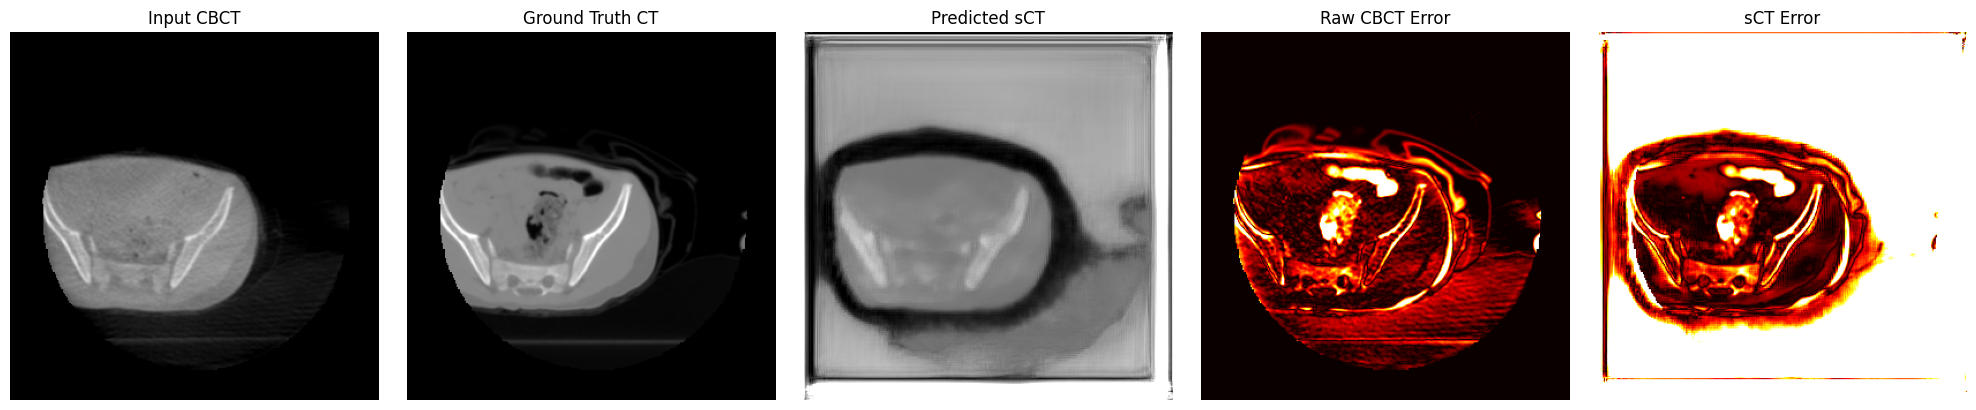

In [12]:
os.makedirs("results/figures/predictions", exist_ok=True)

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(input_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(target_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Ground Truth CT")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(pred_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Predicted sCT")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(raw_error_hu, cmap="hot", vmin=0, vmax=500)
plt.title("Raw CBCT Error")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(error_hu, cmap="hot", vmin=0, vmax=500)
plt.title("sCT Error")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/predictions/day8_prediction_with_metrics.png", dpi=200)
plt.show()

In [13]:
all_metrics = []

model.eval()

max_batches = 50

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if i >= max_batches:
            break

        inputs = batch["input"].to(device)
        targets = batch["target"].to(device)
        masks = batch["mask"].to(device)

        outputs = model(inputs)

        input_center = inputs[0, 3].cpu().numpy()
        target_slice = targets[0, 0].cpu().numpy()
        pred_slice = outputs[0, 0].cpu().numpy()
        mask_slice = masks[0, 0].cpu().numpy()

        metrics = calculate_all_metrics(
            pred_norm=pred_slice,
            target_norm=target_slice,
            input_norm=input_center,
            mask=mask_slice,
            min_hu=-1000,
            max_hu=1600
        )

        metrics["sample_index"] = i
        metrics["patient_id"] = batch["patient_id"][0]
        metrics["slice_index"] = int(batch["slice_index"][0])

        all_metrics.append(metrics)

multi_metrics_df = pd.DataFrame(all_metrics)
multi_metrics_df.to_csv("results/metrics/day8_first50_validation_metrics.csv", index=False)

multi_metrics_df.head()

,sct_mae_hu,sct_rmse_hu,sct_psnr,sct_ssim,raw_cbct_mae_hu,raw_cbct_rmse_hu,raw_cbct_psnr,raw_cbct_ssim,sct_mae_air_lung_hu,raw_cbct_mae_air_lung_hu,sct_mae_soft_tissue_hu,raw_cbct_mae_soft_tissue_hu,sct_mae_bone_hu,raw_cbct_mae_bone_hu,sct_mae_body_hu,raw_cbct_mae_body_hu,sample_index,patient_id,slice_index
0,132.615128,207.139328,21.974218,-0.008212,134.806808,210.962479,21.815365,0.809854,217.804031,224.422073,77.679573,85.452202,237.261337,204.646393,132.615128,134.806808,0,2ABA006,6
1,132.341049,214.610001,21.666470,0.030344,134.722763,225.015656,21.255211,0.838413,242.109619,239.180161,79.753075,81.246460,174.622665,191.291168,132.341049,134.722763,1,2ABA006,7
2,129.651749,221.711685,21.383696,0.025806,134.311356,231.728653,20.999872,0.826761,233.653336,229.552017,68.844223,86.173409,223.475739,184.288040,129.651749,134.311356,2,2ABA006,8
3,123.306702,208.353043,21.923470,0.032839,132.732239,222.441833,21.355137,0.823233,222.625397,219.898834,62.870918,86.721054,197.361801,170.173721,123.306702,132.732239,3,2ABA006,9
4,128.539017,220.777359,21.420376,0.025384,137.752563,228.942841,21.104927,0.812477,244.566238,231.350449,63.227413,86.948799,183.588760,175.413712,128.539017,137.752563,4,2ABA006,10


In [14]:
summary_cols = [
    "raw_cbct_mae_hu",
    "sct_mae_hu",
    "raw_cbct_rmse_hu",
    "sct_rmse_hu",
    "raw_cbct_psnr",
    "sct_psnr",
    "raw_cbct_ssim",
    "sct_ssim"
]

summary = multi_metrics_df[summary_cols].agg(["mean", "std"])
summary

,raw_cbct_mae_hu,sct_mae_hu,raw_cbct_rmse_hu,sct_rmse_hu,raw_cbct_psnr,sct_psnr,raw_cbct_ssim,sct_ssim
mean,185.135452,169.537460,274.583832,277.776764,19.645027,19.552366,0.754579,0.043309
std,36.619167,31.441216,45.285667,46.742485,1.464260,1.518690,0.043550,0.035276


In [15]:
summary.to_csv("results/metrics/day8_first50_validation_summary.csv")
summary

,raw_cbct_mae_hu,sct_mae_hu,raw_cbct_rmse_hu,sct_rmse_hu,raw_cbct_psnr,sct_psnr,raw_cbct_ssim,sct_ssim
mean,185.135452,169.537460,274.583832,277.776764,19.645027,19.552366,0.754579,0.043309
std,36.619167,31.441216,45.285667,46.742485,1.464260,1.518690,0.043550,0.035276


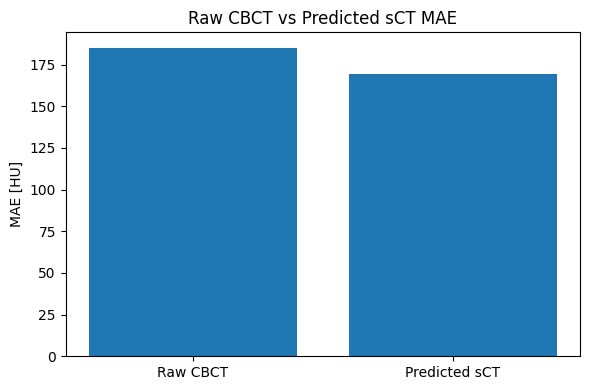

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["Raw CBCT", "Predicted sCT"],
    [
        multi_metrics_df["raw_cbct_mae_hu"].mean(),
        multi_metrics_df["sct_mae_hu"].mean()
    ]
)
plt.ylabel("MAE [HU]")
plt.title("Raw CBCT vs Predicted sCT MAE")
plt.tight_layout()
plt.savefig("results/figures/predictions/day8_raw_vs_sct_mae.png", dpi=200)
plt.show()